In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **بخش اول : درک ساختار داده ها و بررسی اولیه**

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DataMiningCourse/train.csv')

numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()
print("Train Data")
print(f"Number of samples: {len(data)}")
print(f"Number of features: {len(data.columns)}")
print(f"Number of Numeric Columns: {len(numeric_cols)}")
print(f"Number of Categorical Columns: {len(categorical_cols)}")

Train Data
Number of samples: 1460
Number of features: 81
Number of Numeric Columns: 38
Number of Categorical Columns: 43


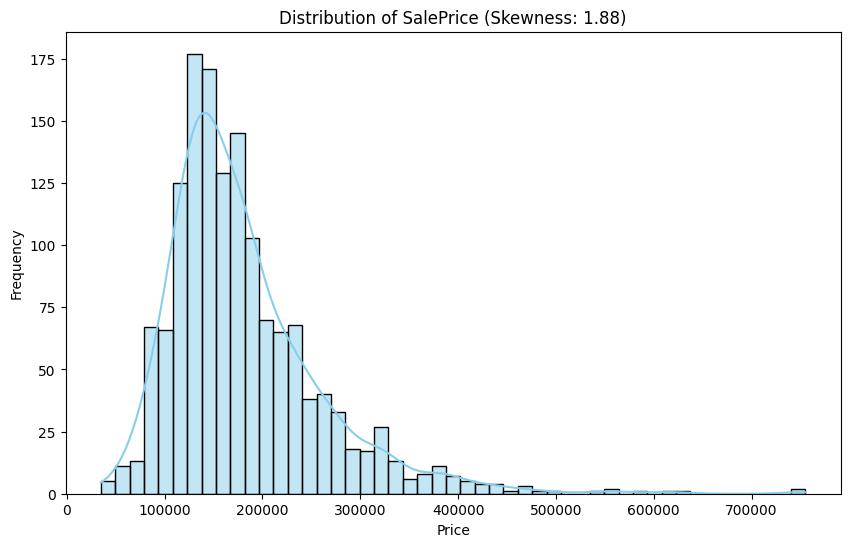

In [ ]:
skewness = data[numeric_cols].skew().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.histplot(data['SalePrice'], kde=True, color='skyblue')
plt.title(f'Distribution of SalePrice (Skewness: {skewness["SalePrice"]:.2f})')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# **بخش دوم : پیش پردازش داده ها**

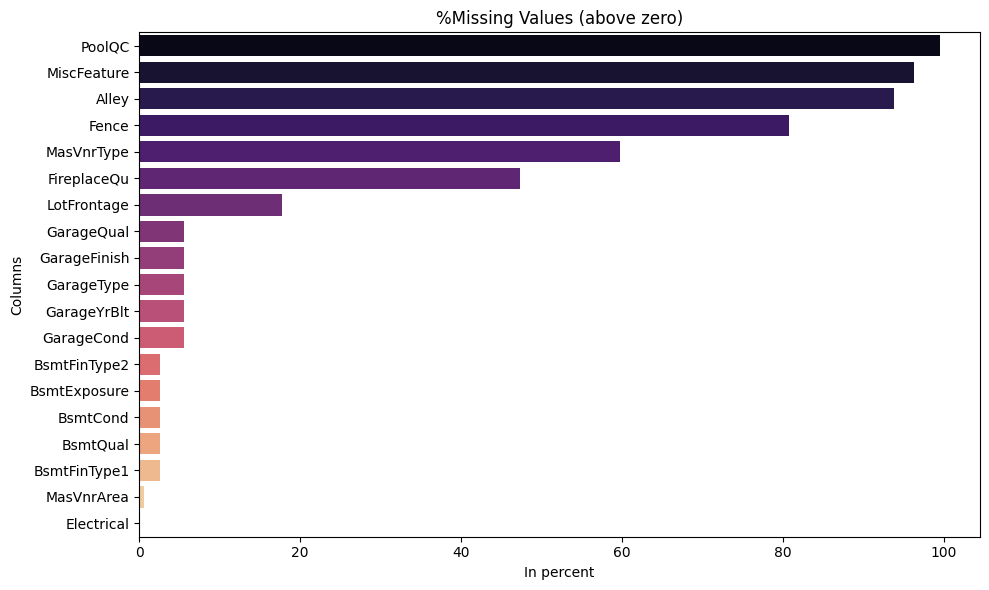

In [ ]:
mv = data.isnull().sum()
mp = (mv / len(data)) * 100
ms = pd.DataFrame({
    'col': mv.index,
    'count': mv.values,
    'pct': mp.values
}).sort_values('pct', ascending=False)
ms = ms[ms['count'] > 0]
plt.figure(figsize=(10, 6))
sns.barplot(x='pct', y='col', data=ms, hue='col',  palette='magma',legend=False)
plt.title('%Missing Values (above zero)')
plt.xlabel('In percent')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

In [ ]:
DropCutoff=80

missing = data.isnull().mean() * 100
drop_cols = missing[missing > DropCutoff].index
print(f"Dropped columns : {list(drop_cols)}")
CleanData = data.drop(columns=drop_cols)

Dropped columns : ['Alley', 'PoolQC', 'Fence', 'MiscFeature']


In [ ]:
### for test
print(len(CleanData), len(CleanData.columns))

1460 77


In [ ]:
from sklearn.impute import SimpleImputer

def impute(data, cutoff):
    df = data.copy()

    num_cols = df.select_dtypes(include='number').columns
    cat_cols = df.select_dtypes(exclude='number').columns
    num_missing = df[num_cols].isnull().mean()
    cat_missing = df[cat_cols].isnull().mean()
    simple_num = num_missing[num_missing <= cutoff].index
    simple_cat = cat_missing[cat_missing <= cutoff].index

    if not simple_num.empty:
        num_imputer = SimpleImputer(strategy='median')
        df[simple_num] = num_imputer.fit_transform(df[simple_num])

    if not simple_cat.empty:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        df[simple_cat] = cat_imputer.fit_transform(df[simple_cat])
    return df

ImputedData = impute(CleanData, cutoff=0.2)
missing_cols = CleanData.columns[CleanData.isnull().any()].tolist()
print("Train Data Missing values before imputation:")
print(CleanData[missing_cols].isnull().sum())
print("\nMissing values after imputation:")
print(ImputedData[missing_cols].isnull().sum())

Train Data Missing values before imputation:
LotFrontage     259
MasVnrType      872
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
FireplaceQu     690
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

Missing values after imputation:
LotFrontage       0
MasVnrType      872
MasVnrArea        0
BsmtQual          0
BsmtCond          0
BsmtExposure      0
BsmtFinType1      0
BsmtFinType2      0
Electrical        0
FireplaceQu     690
GarageType        0
GarageYrBlt       0
GarageFinish      0
GarageQual        0
GarageCond        0
dtype: int64


# **بخش سوم : تشخیص و برخورد با نقاط پرت**

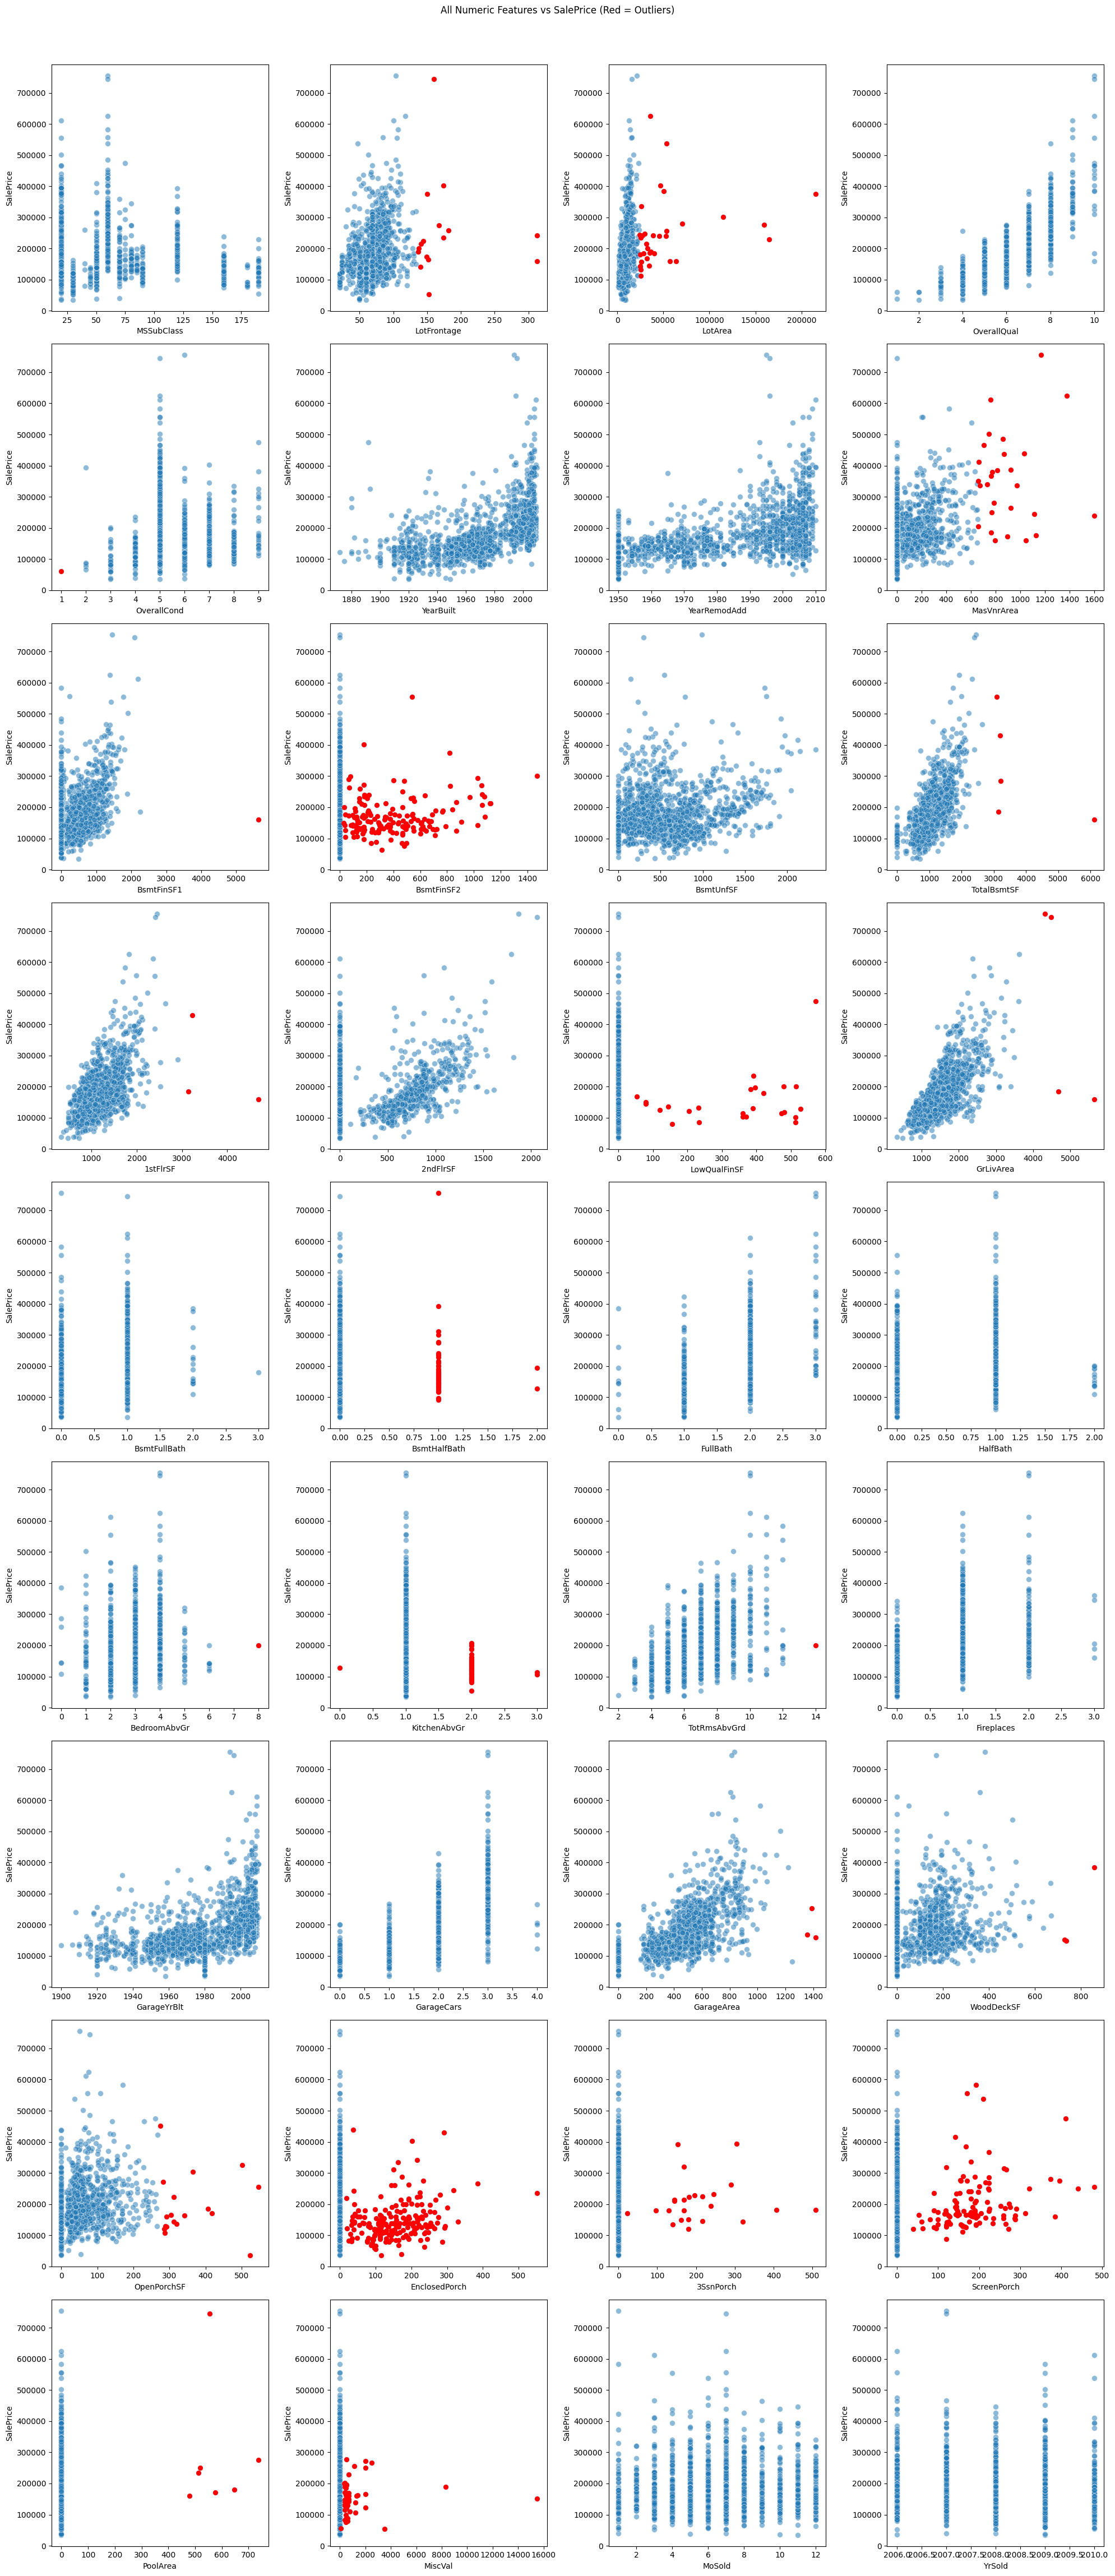

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_features = ImputedData.select_dtypes(include=['int64', 'float64']).columns
numeric_features = [f for f in numeric_features if f not in ['Id', 'SalePrice']]

n_cols = 4
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 5*n_rows))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(x=feature, y='SalePrice', data=ImputedData, alpha=0.5, s=50)
    #### IQR-based outlier detection  ####
    q1 = ImputedData[feature].quantile(0.25)
    q3 = ImputedData[feature].quantile(0.75)
    iqr = q3 - q1
    outliers = ImputedData[(ImputedData[feature] < q1-3*iqr) | (ImputedData[feature] > q3+3*iqr)]
    plt.scatter(outliers[feature], outliers['SalePrice'], color='red', s=30)

plt.tight_layout()
plt.suptitle("All Numeric Features vs SalePrice (Red = Outliers)", y=1.02)
plt.show()

In [ ]:
def winsorize_data(data, lower=0.05, upper=0.95, skip_cols=['Id', 'SalePrice']):
    data_clean = data.copy()
    num_cols = data.select_dtypes(include=['int64', 'float64']).columns

    for col in num_cols:
        if col not in skip_cols:
            low = data[col].quantile(lower)
            high = data[col].quantile(upper)
            data_clean[col] = data[col].clip(low, high)

    return data_clean

WinsorizeData = winsorize_data(ImputedData)
print(WinsorizeData.shape)

(1460, 77)


In [ ]:
def remove_high_cardinalities(df, max_unique_values=10):
    categorical_features = df.select_dtypes(include=["object"]).columns
    columns_to_drop = []

    for feature in categorical_features:
        unique_count = df[feature].nunique()
        if unique_count > max_unique_values:
            print(f"Removed '{feature}' (has {unique_count} unique values)")
            columns_to_drop.append(feature)

    if columns_to_drop:
        df.drop(columns=columns_to_drop, inplace=True)

    return df

CardinalityData = remove_high_cardinalities(WinsorizeData)
print(len(CardinalityData), len(CardinalityData.columns))

Removed 'Neighborhood' (has 25 unique values)
Removed 'Exterior1st' (has 15 unique values)
Removed 'Exterior2nd' (has 16 unique values)
1460 74


In [ ]:
def encode_data(df):
    cat_features = df.select_dtypes(include=['object', 'category']).columns
    return pd.get_dummies(df, columns=cat_features, drop_first=True, dtype=int )

EncodedData = encode_data(CardinalityData)
print(len(EncodedData), len(EncodedData.columns))

1460 184


In [ ]:
def normalize_data(df):
    numeric_cols = df.select_dtypes(include='number').columns.difference(['SalePrice'])
    feature_means = df[numeric_cols].mean()
    feature_stds = df[numeric_cols].std()
    valid_std_cols = feature_stds[feature_stds != 0].index
    df[numeric_cols] = df[numeric_cols] - feature_means
    df[valid_std_cols] = df[valid_std_cols] / feature_stds[valid_std_cols]

    return df

NormalizedData = normalize_data(EncodedData)
print(len(NormalizedData), len(NormalizedData.columns))

1460 184


In [ ]:
from sklearn.model_selection import train_test_split
NormalizedData, NormalizedTestData = train_test_split(NormalizedData, test_size=0.2, random_state=42)
print(len(NormalizedData), len(NormalizedData.columns))
print(len(NormalizedTestData), len(NormalizedTestData.columns))

1168 184
292 184


# **بخش چهارم : پیاده سازی رگرسیون خطی از صفر**

In [ ]:
X_train = NormalizedData.drop('SalePrice', axis=1)
y_train = NormalizedData['SalePrice']
X_test = NormalizedTestData.drop('SalePrice', axis=1)
y_test = NormalizedTestData['SalePrice']

In [ ]:
import numpy as np

def predict(X, w):
    X_bias = np.hstack((np.ones((X.shape[0], 1)), X))
    return X_bias @ w

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def train_linear_regression(X, y, learning_rate=0.01, max_iter=5000, lambda_=0):
    m = X.shape[0]
    X_bias = np.hstack((np.ones((m, 1)), X))
    w = np.zeros(X_bias.shape[1])
    for i in range(max_iter):
        y_pred = X_bias @ w
        gradient = (1/m) * (X_bias.T @ (y_pred - y)) + lambda_ * np.r_[0, w[1:]]
        w -= learning_rate * gradient
        if i % 1000 == 0:
            print(f"Iteration {i}: RMSE = {rmse(y, y_pred):.4f}")
    return w

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

X_train = NormalizedData.drop('SalePrice', axis=1).values
y_train = NormalizedData['SalePrice'].values
X_test = NormalizedTestData.drop('SalePrice', axis=1).values
y_test = NormalizedTestData['SalePrice'].values

weights = train_linear_regression(X_train, y_train, learning_rate=0.001, max_iter=8000, lambda_=0.1)

y_train_pred = predict(X_train, weights)
y_test_pred = predict(X_test, weights)

print(f"Train RMSE: {rmse(y_train, y_train_pred):.4f}")
print(f"Test RMSE: {rmse(y_test, y_test_pred):.4f}")
print(f"Train R^2: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R^2: {r2_score(y_test, y_test_pred):.4f}")

Iteration 0: RMSE = 197194.2786
Iteration 1000: RMSE = 72945.3780
Iteration 2000: RMSE = 38447.0857
Iteration 3000: RMSE = 30081.8391
Iteration 4000: RMSE = 28311.2636
Iteration 5000: RMSE = 27811.2541
Iteration 6000: RMSE = 27582.4145
Iteration 7000: RMSE = 27439.4966
Train RMSE: 27337.9045
Test RMSE: 36987.3819
Train R^2: 0.8747
Test R^2: 0.8216


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
test_pred = sk_model.predict(X_test)

test_mse = mean_squared_error(y_test, test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, test_pred)

print(f"{'Test MSE:':<10} {test_mse:,.2f}")
print(f"{'Test R^2:':<10} {test_r2:.4f}")

Test MSE:  1,461,025,233.95
Test R^2:  0.8095


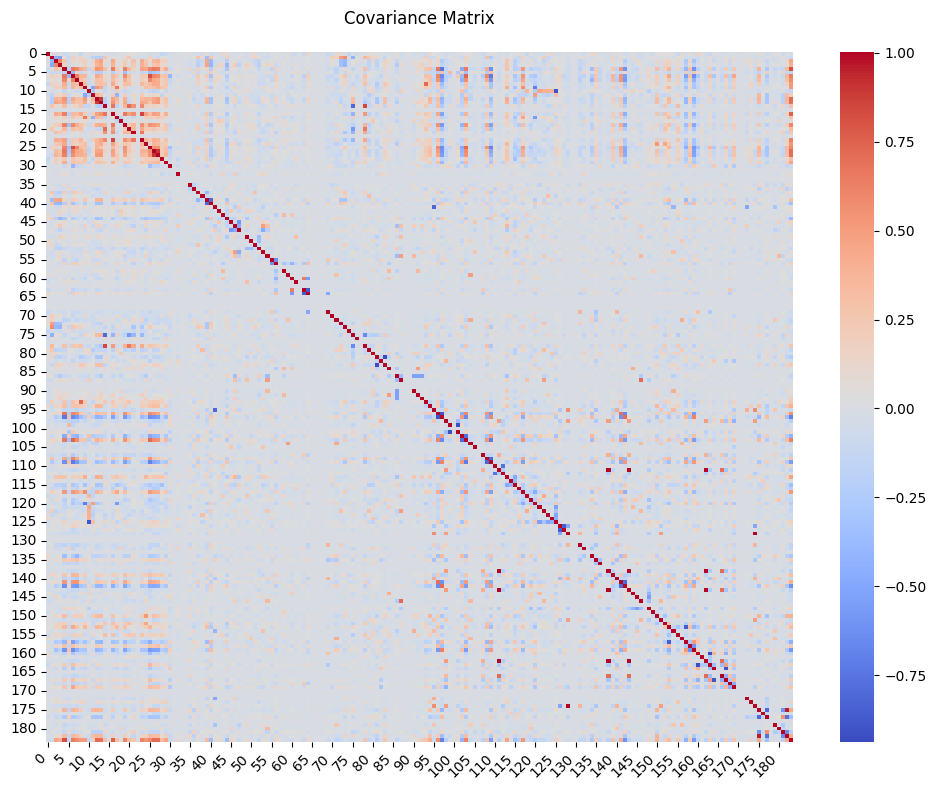

In [ ]:
from sklearn.preprocessing import StandardScaler

test_results = pd.DataFrame(X_test)
test_results.columns = test_results.columns.astype(str)
test_results['predicted_price'] = y_test_pred
scaler = StandardScaler()
scaled_data = scaler.fit_transform(test_results)
scaled_df = pd.DataFrame(scaled_data, columns=test_results.columns)
covariance_matrix = scaled_df.cov()
plt.figure( figsize=( 10, 8 ) )
sns.heatmap( covariance_matrix, cmap='coolwarm' )
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Covariance Matrix", pad=20)

plt.tight_layout()
plt.show()
